In [5]:
import pandas as pd

In [6]:
df = pd.read_csv(r"C:\Users\hp\Downloads\archive\netflix_titles.csv")

In [7]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [8]:
df.shape

(8807, 12)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [10]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [13]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [14]:
df['country'] = df['country'].str.split(',').str[0]

In [15]:
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float)

In [16]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Not Available')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not rated')
df['duration_int'] = df['duration_int'].fillna(df['duration_int'].median())

In [17]:
def categorize(row):
    if row['type'] == 'TV Show':
        return 'TV Show'
    elif row['duration_int'] < 60:
        return 'Short'
    elif row['duration_int'] < 120:
        return 'Medium'
    else:
        return 'Long'
df['content_length_category'] = df.apply(categorize, axis=1)

In [18]:
df['primary_genre'] = df['listed_in'].str.split(',').str[0]

In [19]:
df['release_year'] = df['release_year']
df[['release_year']].head()

,release_year
0,2020
1,2021
2,2021
3,2021
4,2021


In [20]:
print(df.shape)
print(df.isnull().sum())
df.info()

(8807, 17)
show_id                     0
type                        0
title                       0
director                    0
cast                        0
country                     0
date_added                 98
release_year                0
rating                      0
duration                    3
listed_in                   0
description                 0
year_added                 98
month_added                98
duration_int                0
content_length_category     0
primary_genre               0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   show_id                  8807 non-null   str           
 1   type                     8807 non-null   str           
 2   title                    8807 non-null   str           
 3   director                 8807 non-null   str           
 4  

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

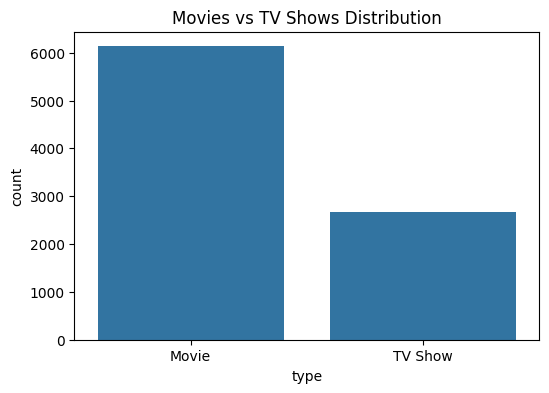

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type')
plt.title("Movies vs TV Shows Distribution")
plt.show()

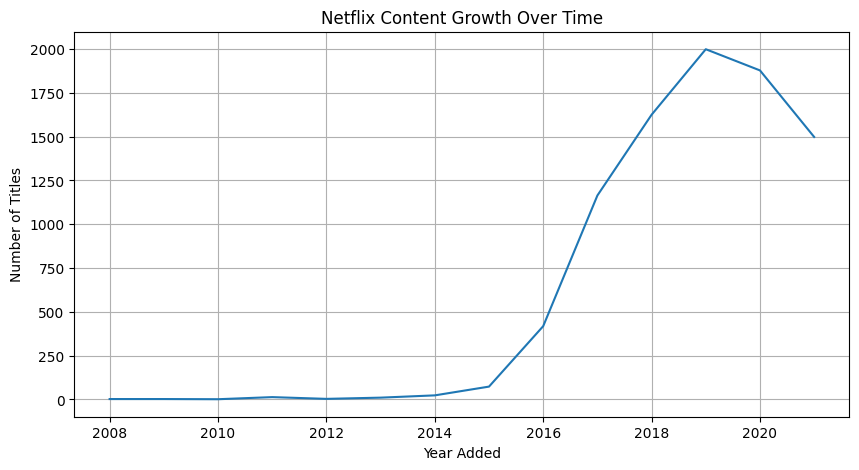

In [23]:
year_growth = df['year_added'].value_counts().sort_index()
plt.figure(figsize=(10,5))
year_growth.plot()
plt.title("Netflix Content Growth Over Time")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.grid()
plt.show()

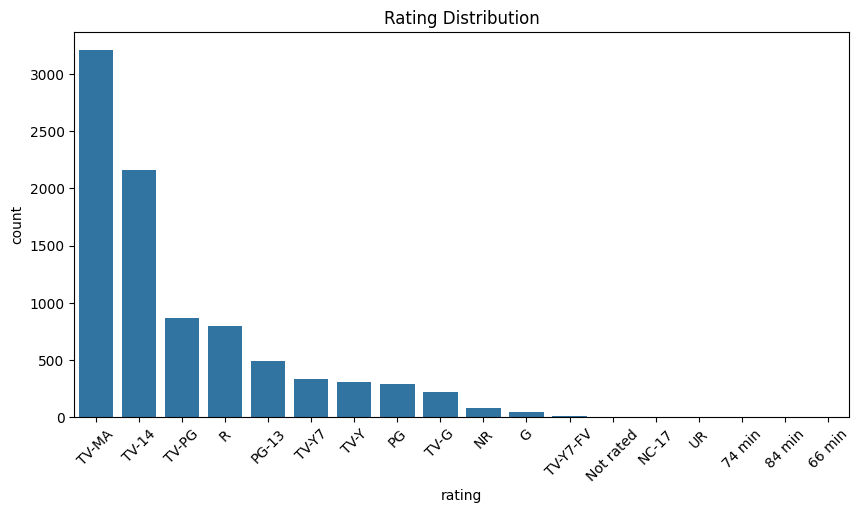

In [25]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Rating Distribution")
plt.show()

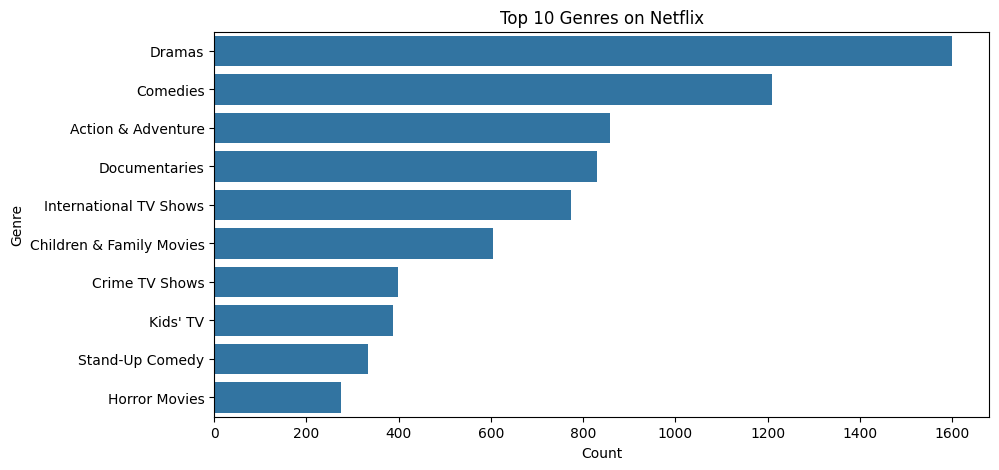

In [27]:
top_genres = df['primary_genre'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

In [28]:
def content_type(row):
    if row['country'] == 'United States' and row['year_added'] >= 2016:
        return 'Original'
    else:
        return 'Licensed'

df['content_origin'] = df.apply(content_type, axis=1)

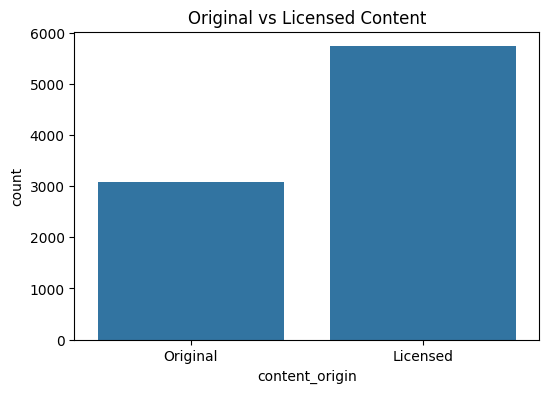

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='content_origin')
plt.title("Original vs Licensed Content")
plt.show()